<a href="https://colab.research.google.com/github/Vanessarttw/abc/blob/main/DEMO.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [135]:
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
import urllib.request

import torch # PyTorch: Deep-Learning Framework für neuronale Netzwerke
import torch.nn.functional as F # Funktionale API von PyTorch
import torchvision.models as models # Torchvision: Vorgefertigte CNN-Modelle
import torchvision.transforms as transforms # Torchvision Transformations: Bild-Preprocessing für CNNs

In [123]:
# vortrainierten CNN
model = models.resnet18(pretrained=True)
model.eval()

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
  

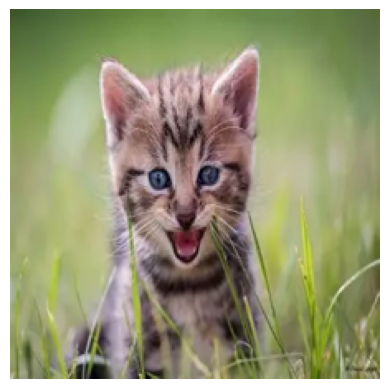

In [124]:
img = Image.open("/content/bsp.webp").convert("RGB")
img = img.resize((224, 224))

plt.imshow(img)
plt.axis("off")
plt.show()

In [125]:
# img = Image.open("/content/hund.webp").convert("RGB")
# img = img.resize((224, 224))

# plt.imshow(img)
# plt.axis("off")
# plt.show()

In [126]:
# Bild in einen PyTorch-Tensor
transform = transforms.Compose([
    transforms.ToTensor()
])

img_tensor = transform(img).unsqueeze(0)

In [127]:
# Speichert die Feature Maps bestimmter Layer während des Forward Passes mittels Hooks
activations = {}

def hook(name):
    def fn(module, input, output):
        activations[name] = output.detach()
    return fn

In [128]:
# Registriert Hooks für alle Convolution-Layer, um deren Feature Maps während des Forward Passes zu speichern
for name, module in model.named_modules():
    if isinstance(module, torch.nn.Conv2d):
        module.register_forward_hook(hook(name))

In [129]:
# Führt einen Forward Pass durch das Netzwerk aus
with torch.no_grad():
    output = model(img_tensor)

In [137]:
# Wandelt die Modell-Ausgabe in Wahrscheinlichkeiten um (Softmax) und gibt die Top-5 vorhergesagten Klassen aus
probs = F.softmax(output[0], dim=0)

top5_prob, top5_catid = torch.topk(probs, 5)

# Lädt ImageNet-Klassennamen aus dem Internet
url = "https://raw.githubusercontent.com/pytorch/hub/master/imagenet_classes.txt"
labels = urllib.request.urlopen(url).read().decode("utf-8").split("\n")

print("Vorhersage:")
for i in range(5):
    print(f"{labels[top5_catid[i]]}: {top5_prob[i].item()*100:.2f}%")

Vorhersage:
lynx: 26.27%
tiger cat: 19.39%
tabby: 15.52%
Egyptian cat: 12.35%
carton: 6.10%


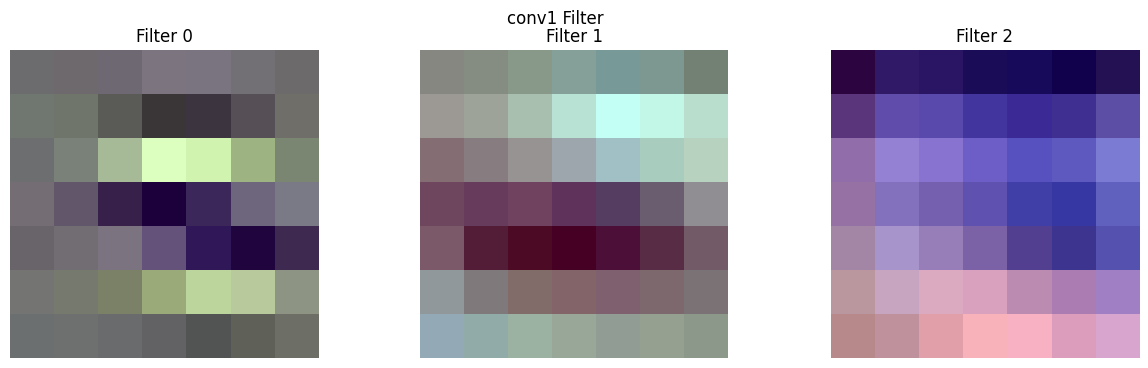

In [131]:
# Filter erster Convolution Layer
filters = model.conv1.weight.data

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for i in range(3):
    f = filters[i].cpu().permute(1, 2, 0)
    f = (f - f.min()) / (f.max() - f.min() + 1e-8)

    axes[i].imshow(f)
    axes[i].axis("off")
    axes[i].set_title(f"Filter {i}")

plt.suptitle("conv1 Filter")
plt.show()

In [132]:
# Architekturparameter
for name, module in model.named_modules():
    if isinstance(module, torch.nn.Conv2d):
        print("\nLayer:", name)
        print("Filter:", module.out_channels)
        print("Input Channels:", module.in_channels)
        print("Kernel Size:", module.kernel_size)
        print("Stride:", module.stride)
        print("Padding:", module.padding)


Layer: conv1
Filter: 64
Input Channels: 3
Kernel Size: (7, 7)
Stride: (2, 2)
Padding: (3, 3)

Layer: layer1.0.conv1
Filter: 64
Input Channels: 64
Kernel Size: (3, 3)
Stride: (1, 1)
Padding: (1, 1)

Layer: layer1.0.conv2
Filter: 64
Input Channels: 64
Kernel Size: (3, 3)
Stride: (1, 1)
Padding: (1, 1)

Layer: layer1.1.conv1
Filter: 64
Input Channels: 64
Kernel Size: (3, 3)
Stride: (1, 1)
Padding: (1, 1)

Layer: layer1.1.conv2
Filter: 64
Input Channels: 64
Kernel Size: (3, 3)
Stride: (1, 1)
Padding: (1, 1)

Layer: layer2.0.conv1
Filter: 128
Input Channels: 64
Kernel Size: (3, 3)
Stride: (2, 2)
Padding: (1, 1)

Layer: layer2.0.conv2
Filter: 128
Input Channels: 128
Kernel Size: (3, 3)
Stride: (1, 1)
Padding: (1, 1)

Layer: layer2.0.downsample.0
Filter: 128
Input Channels: 64
Kernel Size: (1, 1)
Stride: (2, 2)
Padding: (0, 0)

Layer: layer2.1.conv1
Filter: 128
Input Channels: 128
Kernel Size: (3, 3)
Stride: (1, 1)
Padding: (1, 1)

Layer: layer2.1.conv2
Filter: 128
Input Channels: 128
Kernel

In [138]:
# Visualisierung Feature Maps
def show_feature_maps(name, n=3):
    feat = activations[name][0]

    fig, axes = plt.subplots(1, n, figsize=(15, 4))

    for i in range(n):
        axes[i].imshow(feat[i].cpu(), cmap="viridis")
        axes[i].axis("off")
        axes[i].set_title(f"Kanal {i}")

    plt.suptitle(f"Feature Maps: {name}")
    plt.show()

Zeige: conv1


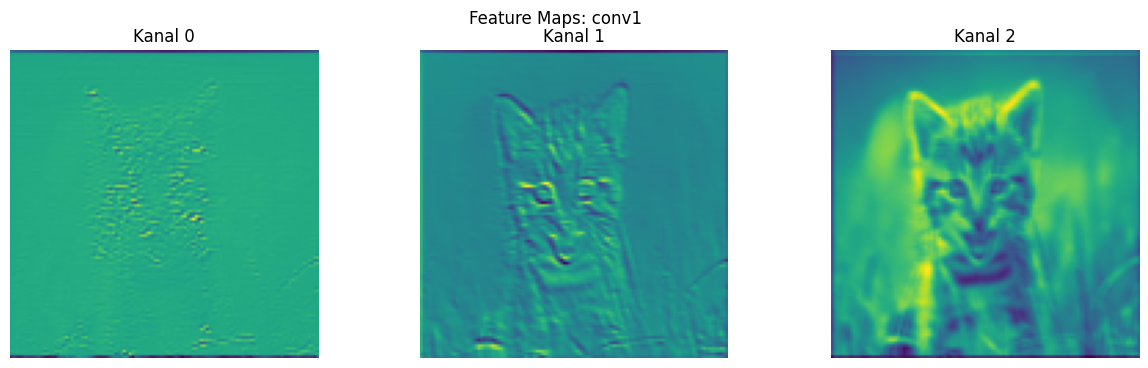

Zeige: layer1.0.conv1


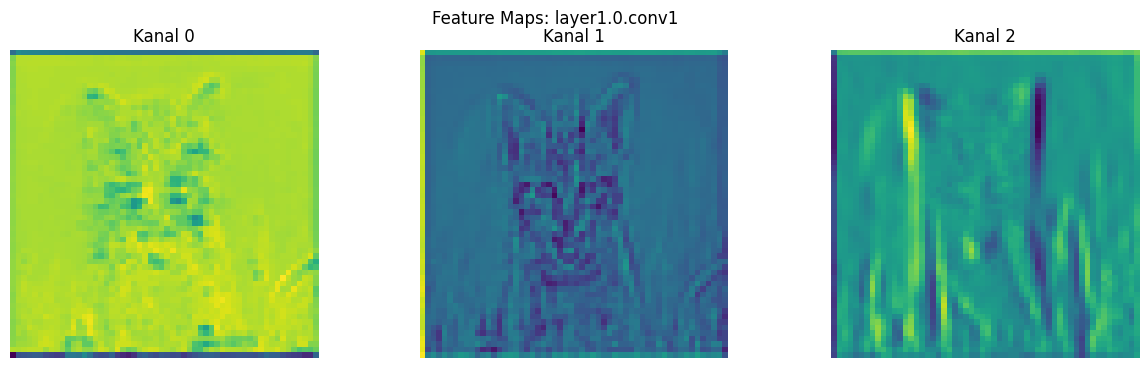

Zeige: layer1.0.conv2


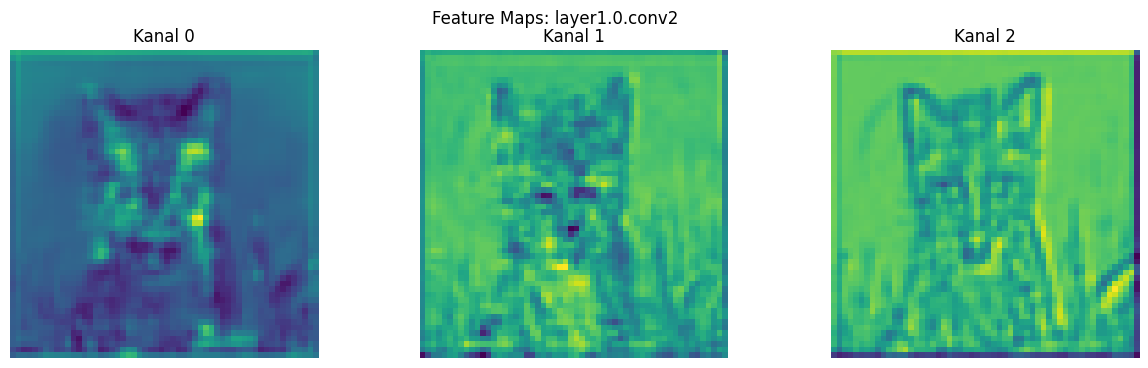

Zeige: layer1.1.conv1


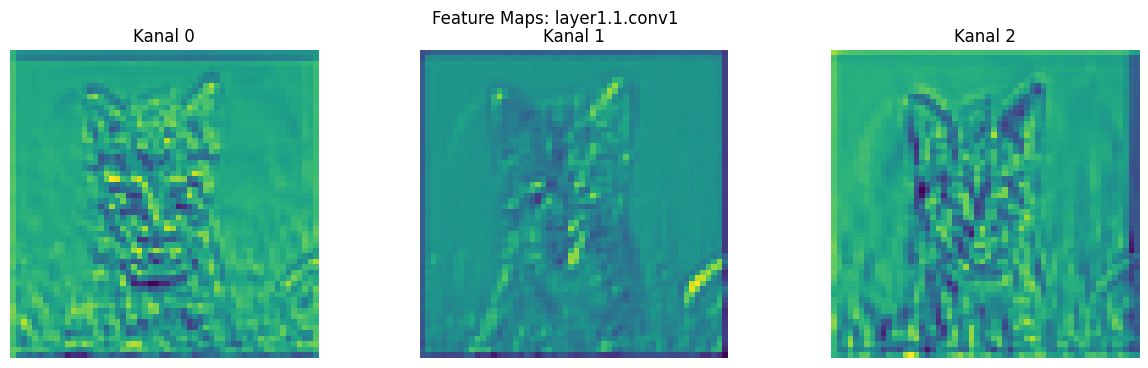

Zeige: layer1.1.conv2


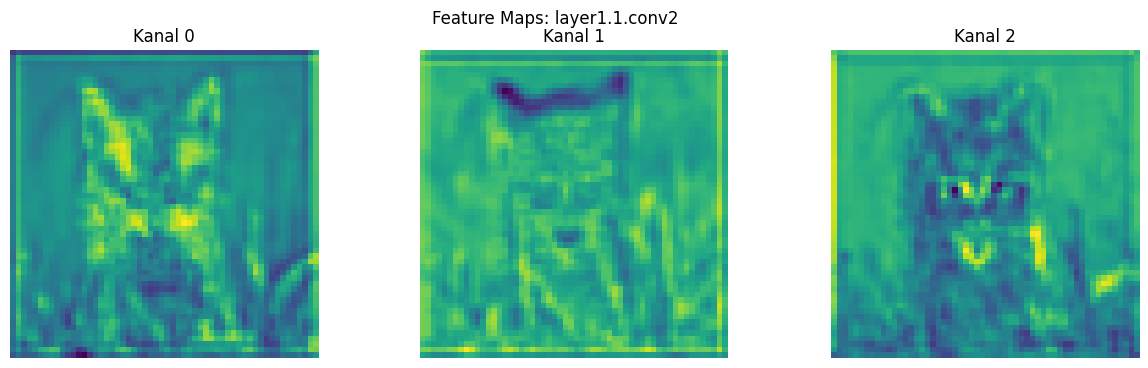

Zeige: layer2.0.conv1


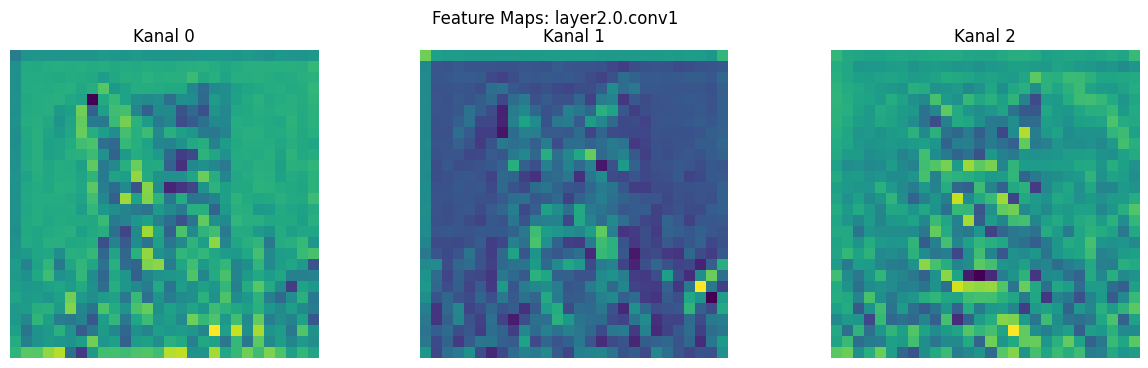

Zeige: layer2.0.conv2


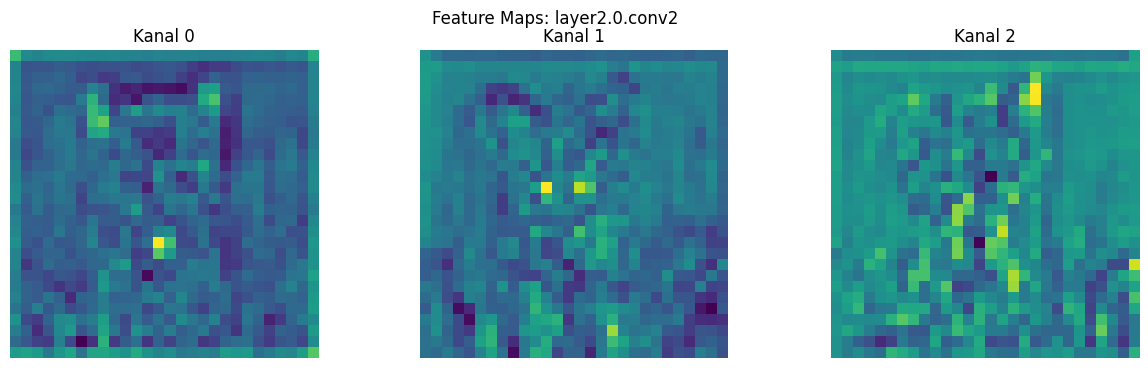

Zeige: layer2.0.downsample.0


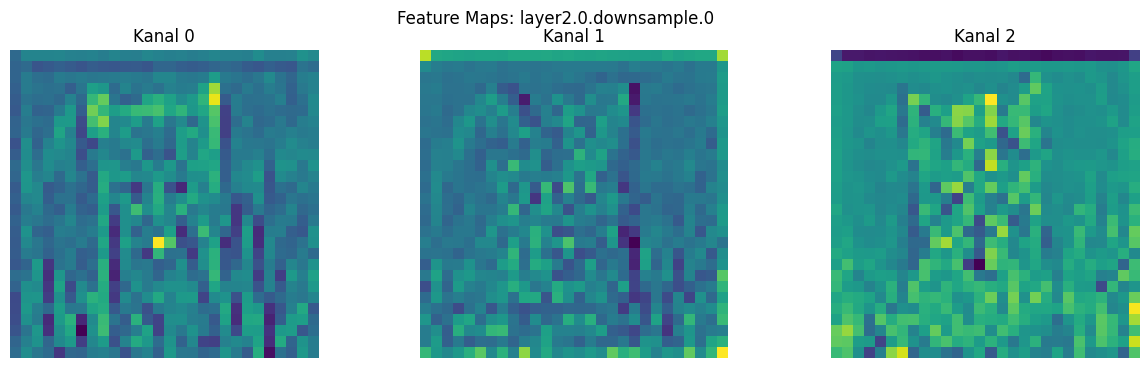

Zeige: layer2.1.conv1


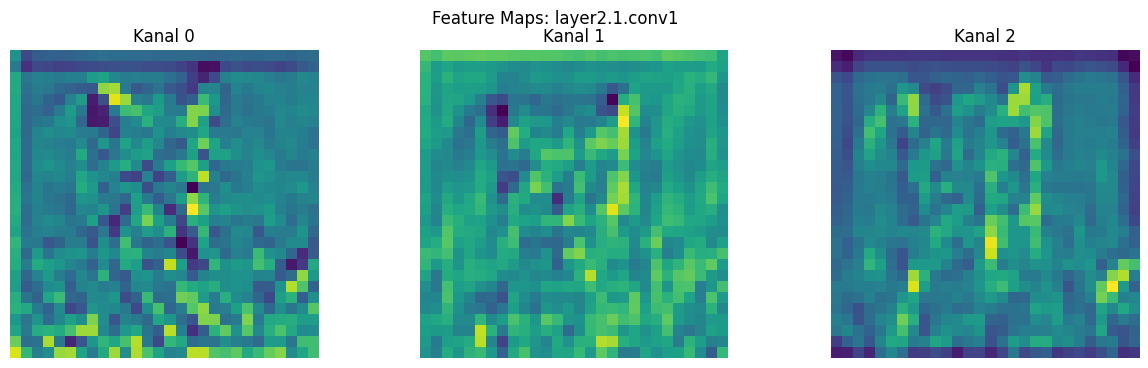

Zeige: layer2.1.conv2


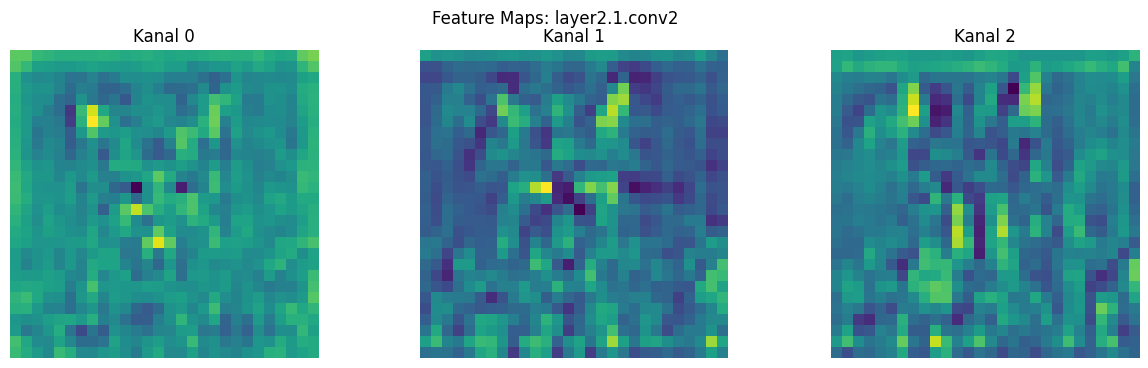

Zeige: layer3.0.conv1


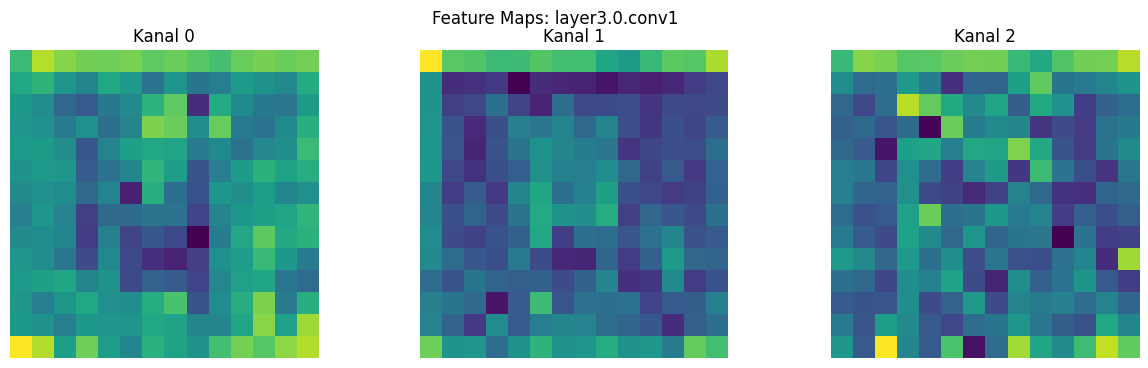

Zeige: layer3.0.conv2


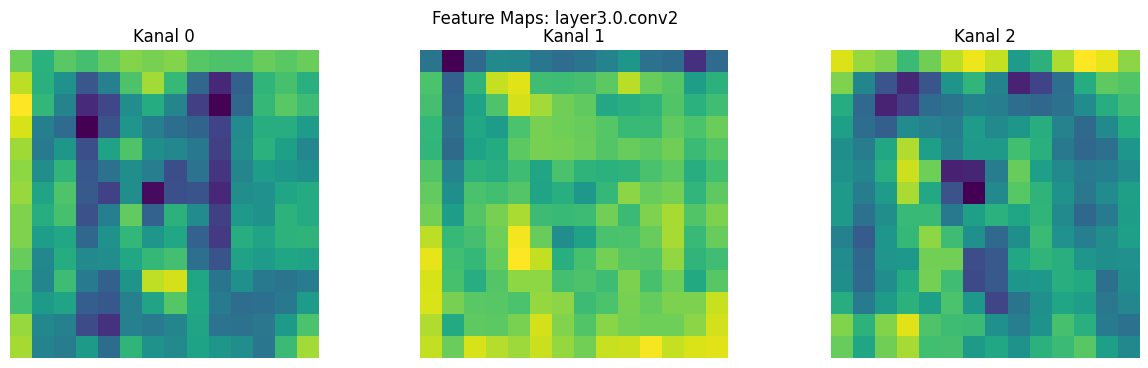

Zeige: layer3.0.downsample.0


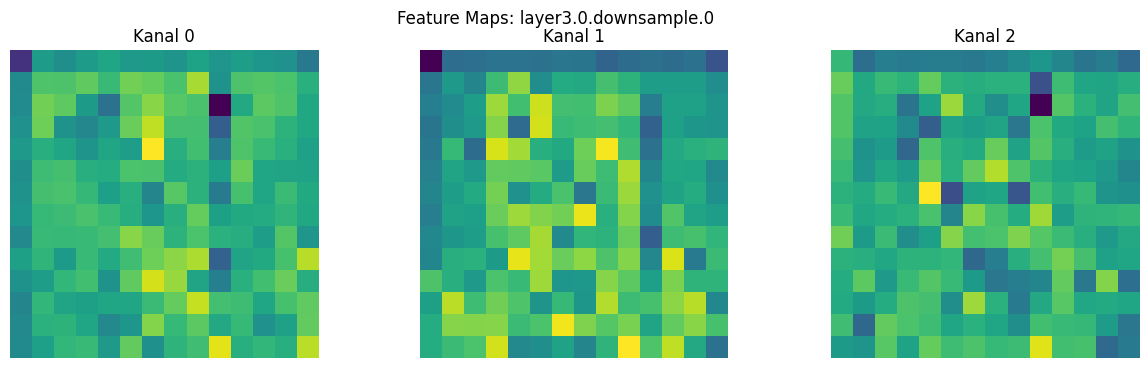

Zeige: layer3.1.conv1


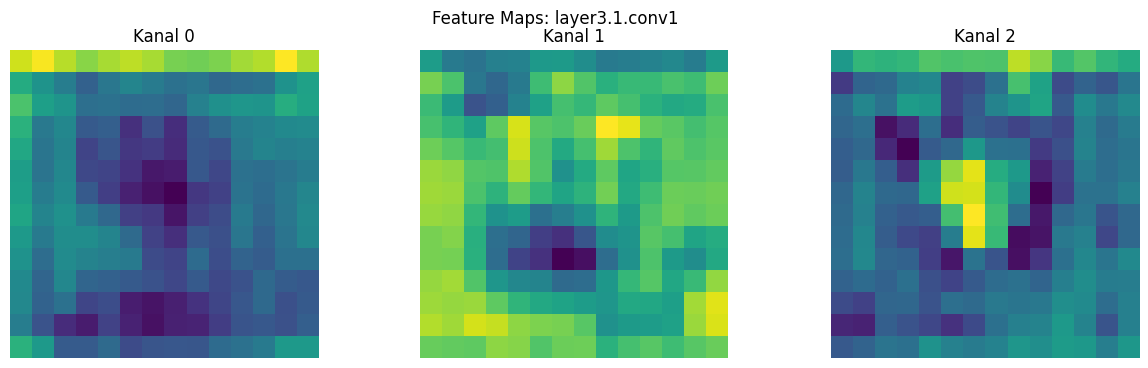

Zeige: layer3.1.conv2


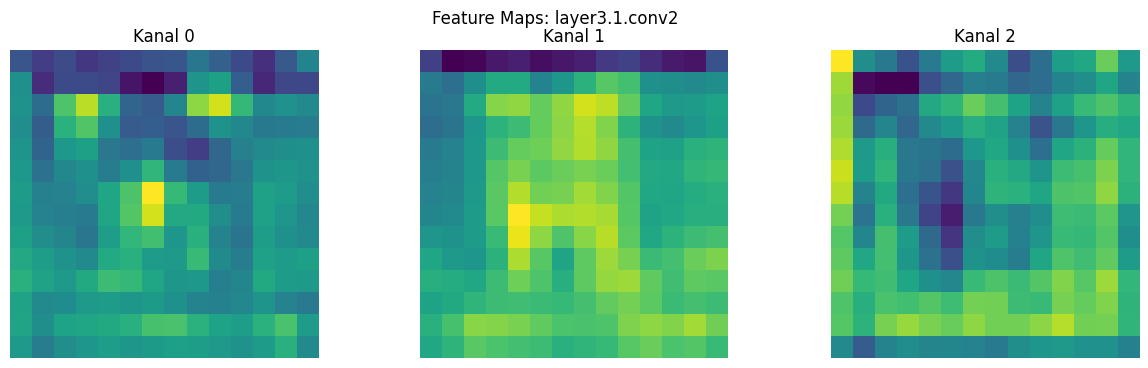

Zeige: layer4.0.conv1


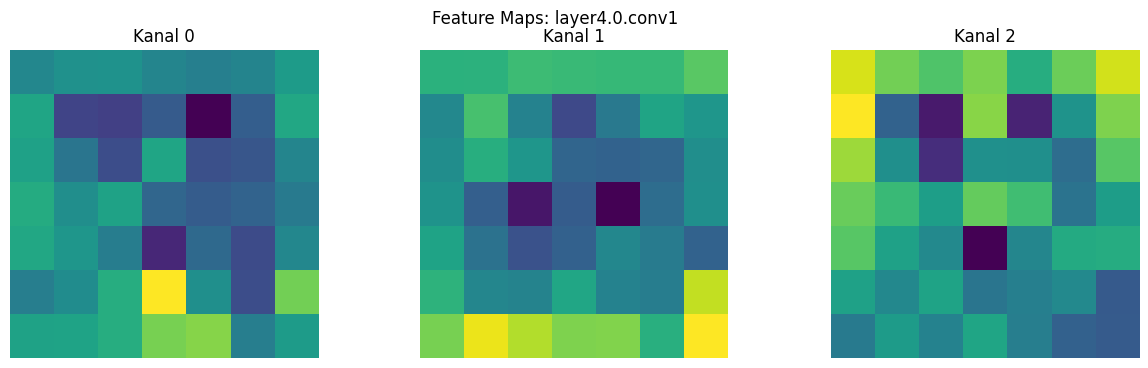

Zeige: layer4.0.conv2


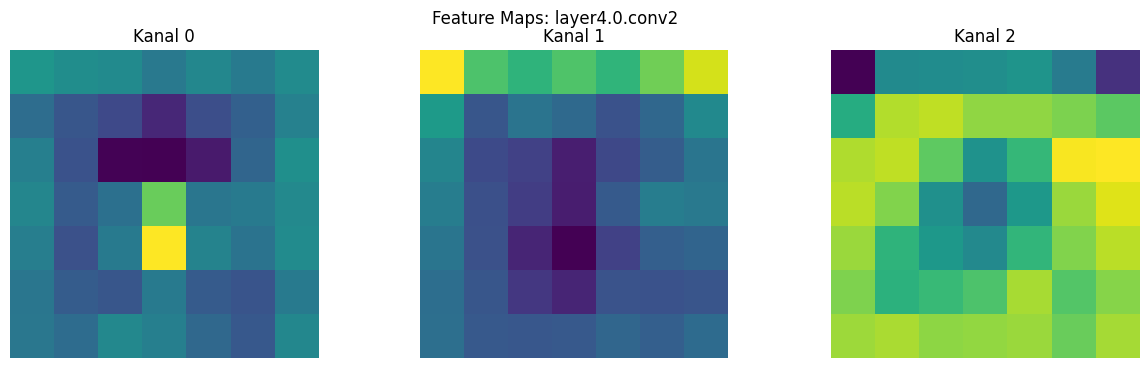

Zeige: layer4.0.downsample.0


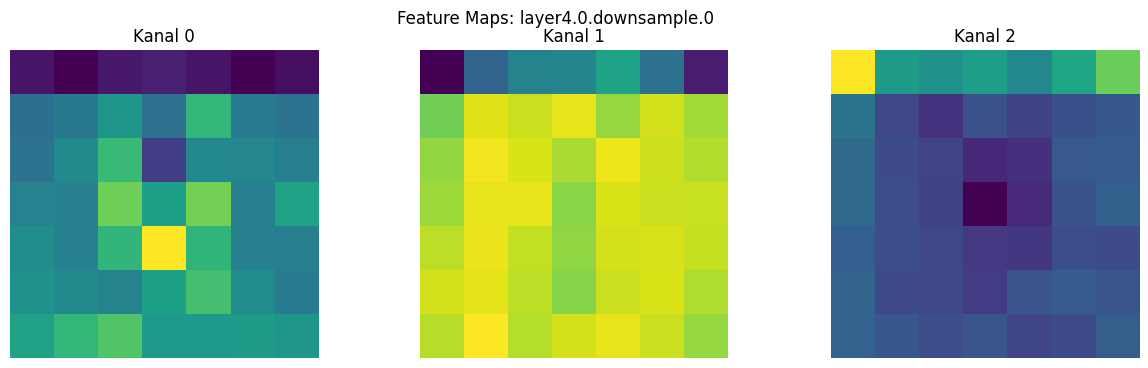

Zeige: layer4.1.conv1


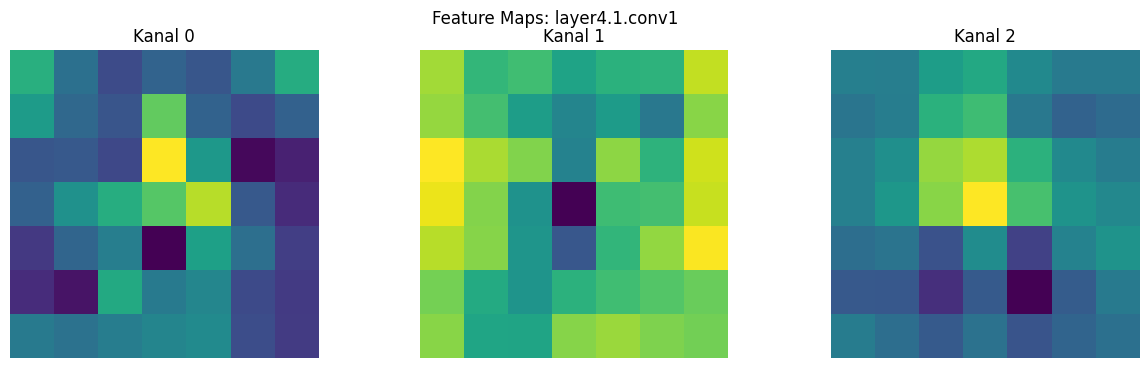

Zeige: layer4.1.conv2


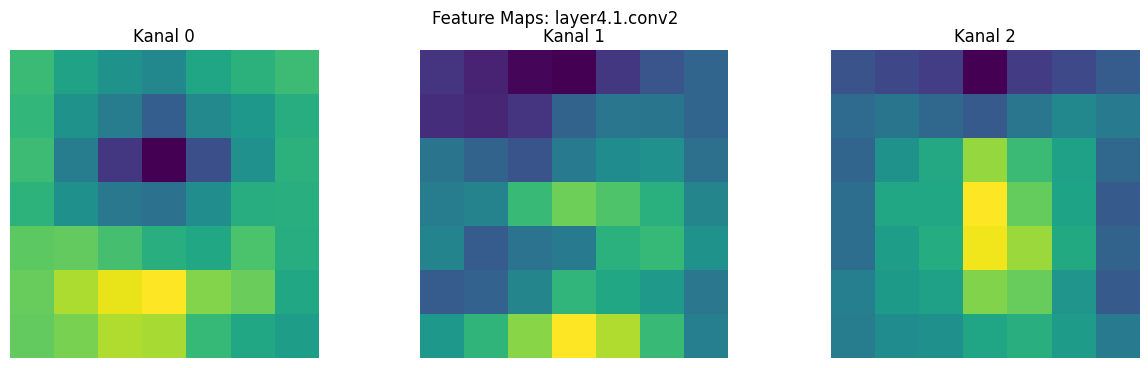

In [134]:
# Feature Maps der einzelnen Layer
conv_layers = [
    name for name, module in model.named_modules()
    if isinstance(module, torch.nn.Conv2d)
]

for name in conv_layers:
    if name in activations:
        print("Zeige:", name)
        show_feature_maps(name)